In [1]:
# Random Forest Implementation for Spoiler Detection
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
from nltk.corpus import stopwords
import string
import re
import spacy

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Load your preprocessed data
combined_df_exploded = pd.read_csv('/content/drive/MyDrive/combined_df_exploded_1.csv')

print(f"Dataset shape: {combined_df_exploded.shape}")
print(f"Columns: {combined_df_exploded.columns.tolist()}")

# Check the distribution of spoilers
print("\nSpoiler distribution:")
print(combined_df_exploded['is_spoiler'].value_counts())

Dataset shape: (205304, 13)
Columns: ['review_date', 'movie_id', 'user_id', 'is_spoiler', 'review_text', 'rating_x', 'review_summary', 'plot_summary', 'duration', 'genre', 'rating_y', 'release_date', 'plot_synopsis']

Spoiler distribution:
is_spoiler
False    152888
True      52416
Name: count, dtype: int64


Features

In [4]:
nltk.download('stopwords')

def preprocess_text(text):
    """Clean and preprocess text for analysis"""
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation
    words = text.split()
    stop_words = set(stopwords.words('english'))
    words = [word for word in words if word not in stop_words and len(word) > 2]
    return ' '.join(words)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [5]:
def count_names_spacy(text, nlp_model):
    """Count person names in text using spaCy"""
    if pd.isna(text):
        return 0
    doc = nlp_model(str(text)[:1000])  # Limit to first 1000 chars
    return sum(1 for ent in doc.ents if ent.label_ == "PERSON")

In [6]:
# Load spaCy model (make sure it's installed)
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    print("Please install spaCy English model: python -m spacy download en_core_web_sm")

# Clean review text
print("Preprocessing text...")

Preprocessing text...


In [7]:
combined_df_exploded['processed_text'] = combined_df_exploded['review_text'].apply(preprocess_text)

# Feature: Text length features
combined_df_exploded['review_length'] = combined_df_exploded['review_text'].str.len()
combined_df_exploded['word_count'] = combined_df_exploded['processed_text'].str.split().str.len()


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [8]:
# Feature: Genre encoding
le_genre = LabelEncoder()
combined_df_exploded['genre_encoded'] = le_genre.fit_transform(combined_df_exploded['genre'].astype(str))


In [9]:
# Feature: Rating
if 'rating' in combined_df_exploded.columns:
    combined_df_exploded['rating'] = pd.to_numeric(combined_df_exploded['rating'], errors='coerce').fillna(0)
else:
    combined_df_exploded['rating'] = 0

In [10]:
# Feature: TF-IDF features from text
print("Creating TF-IDF features...")
tfidf = TfidfVectorizer(
    max_features=1000,  # Top 1000 features
    ngram_range=(1, 2),  # Unigrams and bigrams
    min_df=5,  # Minimum document frequency
    max_df=0.8  # Maximum document frequency
)

Creating TF-IDF features...


In [11]:
# Fit TF-IDF on processed text
tfidf_features = tfidf.fit_transform(combined_df_exploded['processed_text'].fillna(''))
tfidf_df = pd.DataFrame(tfidf_features.toarray(),
                       columns=[f'tfidf_{i}' for i in range(tfidf_features.shape[1])])

In [13]:
# Combine all features
print("Combining features...")
feature_cols = ['review_length', 'word_count', 'genre_encoded', 'rating']
X_basic = combined_df_exploded[feature_cols].fillna(0)


Combining features...


In [14]:
# Reset index to ensure alignment
X_basic = X_basic.reset_index(drop=True)
tfidf_df = tfidf_df.reset_index(drop=True)

In [15]:
# Combine basic features with TF-IDF
X = pd.concat([X_basic, tfidf_df], axis=1)
y = combined_df_exploded['is_spoiler'].reset_index(drop=True)


In [16]:
print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

Feature matrix shape: (205304, 1004)
Target vector shape: (205304,)


Model Training

In [17]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")


Training set: 164243 samples
Test set: 41061 samples


In [18]:
# Basic Random Forest model
print("\nTraining basic Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)


Training basic Random Forest...


In [19]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [20]:
# Make predictions
y_pred_basic = rf_model.predict(X_test)
y_pred_proba_basic = rf_model.predict_proba(X_test)[:, 1]


In [21]:
# Basic model performance
print("\n" + "="*50)
print("BASIC RANDOM FOREST RESULTS")
print("="*50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_basic):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_basic):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_basic))


BASIC RANDOM FOREST RESULTS
Accuracy: 0.9699
ROC-AUC: 0.9925

Classification Report:
              precision    recall  f1-score   support

       False       0.96      1.00      0.98     30578
        True       0.99      0.89      0.94     10483

    accuracy                           0.97     41061
   macro avg       0.98      0.94      0.96     41061
weighted avg       0.97      0.97      0.97     41061



Model Analysis


Top 20 Most Important Features:
           feature  importance
0    review_length    0.020605
1       word_count    0.019071
247      tfidf_243    0.006887
748      tfidf_744    0.006397
583      tfidf_579    0.005253
315      tfidf_311    0.005084
194      tfidf_190    0.004994
629      tfidf_625    0.004809
477      tfidf_473    0.004620
138      tfidf_134    0.004581
512      tfidf_508    0.004266
990      tfidf_986    0.004055
88        tfidf_84    0.003915
364      tfidf_360    0.003838
263      tfidf_259    0.003834
545      tfidf_541    0.003795
887      tfidf_883    0.003602
831      tfidf_827    0.003542
248      tfidf_244    0.003500
381      tfidf_377    0.003465

Actual TF-IDF words:
end: 0.0069
scene: 0.0064
movie: 0.0053
film: 0.0051
death: 0.0050
one: 0.0048
killed: 0.0046
character: 0.0046
like: 0.0043
would: 0.0041
best: 0.0039
get: 0.0038
even: 0.0038
man: 0.0038
time: 0.0036
story: 0.0035
ending: 0.0035
great: 0.0035


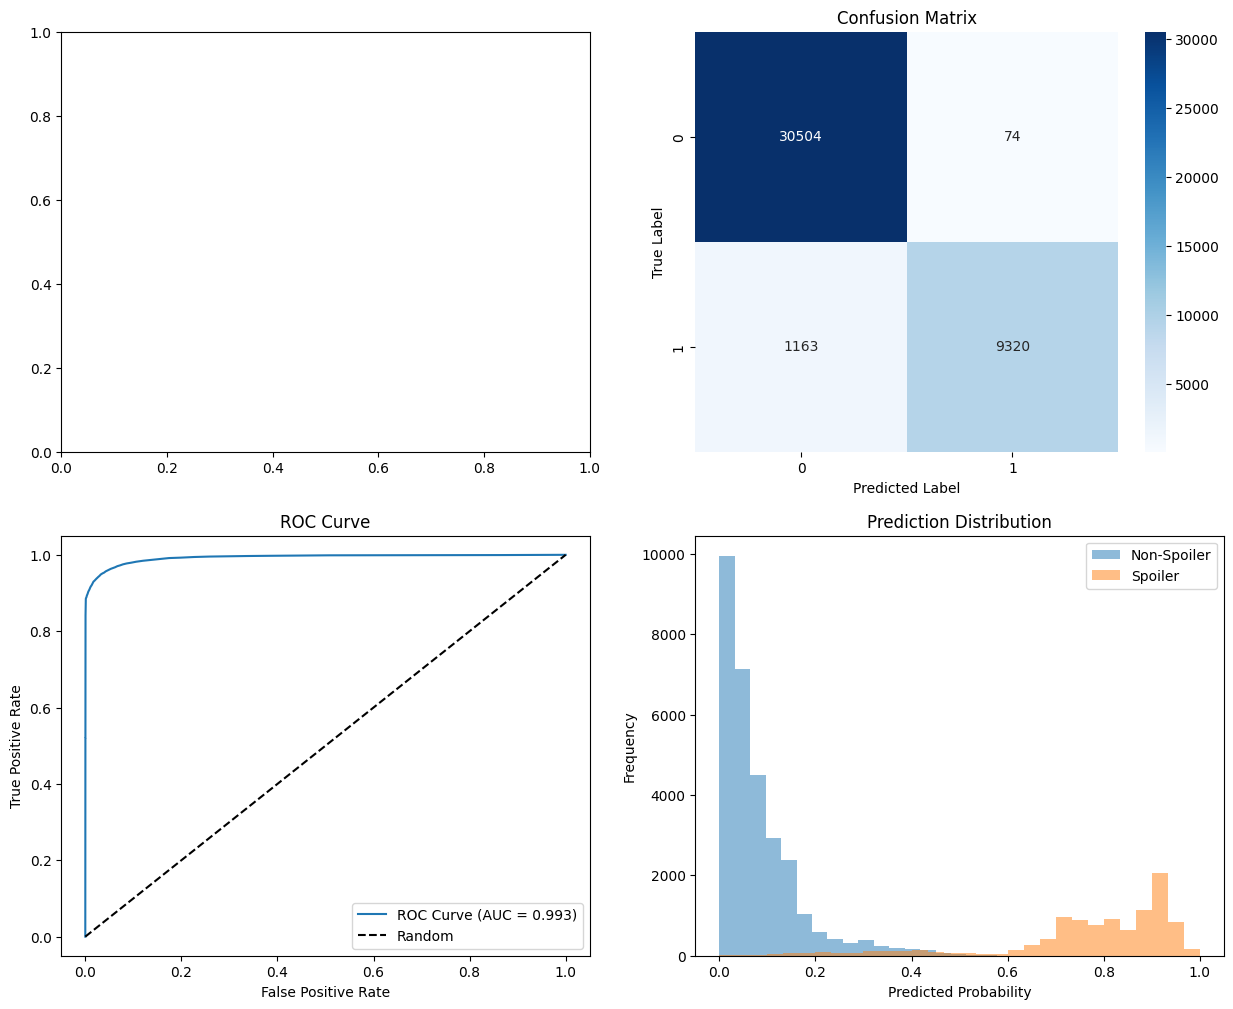

In [23]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 20 Most Important Features:")
print(feature_importance.head(20))

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 2. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_basic)
sns.heatmap(cm, annot=True, fmt='d', ax=axes[0, 1], cmap='Blues')
axes[0, 1].set_title('Confusion Matrix')
axes[0, 1].set_ylabel('True Label')
axes[0, 1].set_xlabel('Predicted Label')

# 3. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_basic)
axes[1, 0].plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_pred_proba_basic):.3f})')
axes[1, 0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[1, 0].set_xlabel('False Positive Rate')
axes[1, 0].set_ylabel('True Positive Rate')
axes[1, 0].set_title('ROC Curve')
axes[1, 0].legend()

# Get the actual TF-IDF feature names
feature_names = tfidf.get_feature_names_out()
print("\nActual TF-IDF words:")
for idx, row in feature_importance.head(20).iterrows():
    if 'tfidf_' in row['feature']:
        tfidf_idx = int(row['feature'].split('_')[1])
        print(f"{feature_names[tfidf_idx]}: {row['importance']:.4f}")

# 4. Prediction Distribution
axes[1, 1].hist(y_pred_proba_basic[y_test == 0], alpha=0.5, label='Non-Spoiler', bins=30)
axes[1, 1].hist(y_pred_proba_basic[y_test == 1], alpha=0.5, label='Spoiler', bins=30)
axes[1, 1].set_xlabel('Predicted Probability')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Prediction Distribution')
axes[1, 1].legend()

This shows that indeed our initial analysis was right that the length of reviews really determines if there are spoilers in it

In [24]:
# ================== CROSS-VALIDATION ==================
print("\nPerforming 5-fold cross-validation...")
cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='roc_auc')  # Changed to rf_basic
print(f"Cross-validation ROC-AUC scores: {cv_scores}")
print(f"Mean CV ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")


Performing 5-fold cross-validation...
Cross-validation ROC-AUC scores: [0.98121448 0.98054033 0.98129348 0.98111732 0.97925624]
Mean CV ROC-AUC: 0.9807 (+/- 0.0015)


In [25]:

# Save the results
results_df = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred_basic,
    'probability': y_pred_proba_basic
})

# Save to CSV
results_df.to_csv('random_forest_predictions.csv', index=False)
feature_importance.to_csv('feature_importance.csv', index=False)

print("\nResults saved to:")
print("- random_forest_predictions.csv")
print("- feature_importance.csv")

# Model summary
print("\n" + "="*50)
print("MODEL SUMMARY")
print("="*50)
print(f"Dataset size: {X.shape[0]} samples, {X.shape[1]} features")
print(f"Best model accuracy: {accuracy_score(y_test, y_pred_basic):.4f}")
print(f"Best model ROC-AUC: {roc_auc_score(y_test, y_pred_proba_basic):.4f}")
print(f"Cross-validation ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
print("Model training completed successfully!")


Results saved to:
- random_forest_predictions.csv
- feature_importance.csv

MODEL SUMMARY
Dataset size: 205304 samples, 1004 features
Best model accuracy: 0.9699
Best model ROC-AUC: 0.9925
Cross-validation ROC-AUC: 0.9807 (+/- 0.0015)
Model training completed successfully!
